In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
from napari_spatialdata import Interactive
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../scripts/utils
import sys
sys.path.append('../scripts')
from utils import _rasterize_bins


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
2025-02-04 10:09:48,415 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.im.flowsom', please install this library.
2

In this notebook, we are going to preprocess the 8um bin size according to the single-cell analysis pipeline.

In [2]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
sc.settings.figdir = "./plots/"

In [3]:
first_run = False

if first_run:
    sdata = spatialdata_io.visium_hd('../data/Visium_HD_Liver',
                                    fullres_image_file="microscope_image/SCA002_HE_hires_transposed.tif",
                                    annotate_table_by_labels=True)
    # Write to zarr
    sdata.write('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')
    del sdata

sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

## QC and preprocessing

We perform some basic filtering of spots based on total counts and expressed genes on the 8um bin

In [4]:
adata = sdata.tables['square_008um']
adata

AnnData object with n_obs × n_vars = 461427 × 17588
    obs: 'cell_ID', 'in_tissue', 'array_row', 'array_col', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'clusters_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [12]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

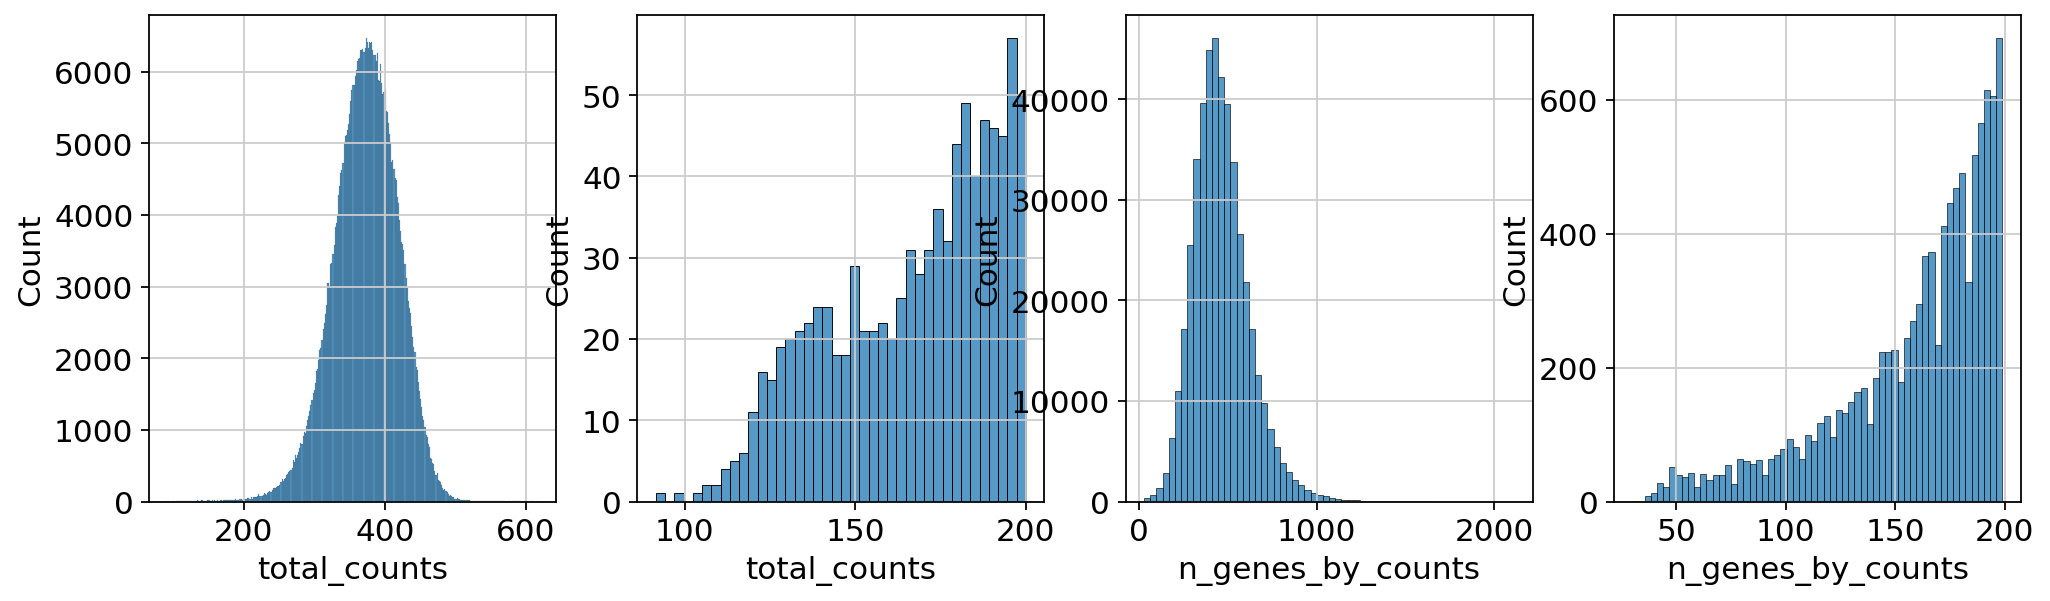

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 200],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 200],
    kde=False,
    bins=60,
    ax=axs[3],
)

In [11]:
sc.pp.filter_cells(adata, min_counts=50)
# sc.pp.filter_cells(adata, max_counts=4000)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

filtered out 842 cells that have less than 50 counts
#cells after MT filter: 461427
filtered out 1471 genes that are detected in less than 10 cells


We proceed to normalize Visium counts data with the built-in `normalize_total` method from Scanpy, and detect highly-variable genes (for later). Note that there are alternatives for normalization (see discussion in [[Luecken19](https://www.embopress.org/doi/full/10.15252/msb.20188746)], and more recent alternatives such as [SCTransform](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1874-1) or [GLM-PCA](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1861-6)).

In [12]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [5]:
# Get zonation markers
zonation_marker_genes = pd.read_csv('final_MERscope_panel_Guilliams1.csv')

# Print the first few rows of the marker_genes dataframe
print(zonation_marker_genes.head())

# Check how many of the "Vizgen Gene" column values are in the adata.var_names
print("{} out of {} genes are in the AnnData".format(zonation_marker_genes['Vizgen Gene'].isin(adata.var_names).sum(), len(zonation_marker_genes)))

# Get value_counts of "Notes" column that starts with cellType_
print(zonation_marker_genes['Notes'][zonation_marker_genes['Notes'].str.startswith('zonation')].value_counts())

# Only get marker genes with cellType_ in the "Notes" column that has more than 10 genes
zonation_marker_genes_subset = zonation_marker_genes[zonation_marker_genes['Notes'].str.startswith('zonation')].copy()
print(zonation_marker_genes_subset)

  Gene Input Vizgen Gene         Ensemble ID          Transcript  \
0       NGFR        Ngfr  ENSMUSG00000000120  ENSMUST00000000122   
1       CCL2        Ccl2  ENSMUSG00000035385  ENSMUST00000000193   
2      CCL12       Ccl12  ENSMUSG00000035352  ENSMUST00000000194   
3         TH          Th  ENSMUSG00000000214  ENSMUST00000000219   
4       LHX2        Lhx2  ENSMUSG00000000247  ENSMUST00000000253   

                         Notes  Abundance  Target Regions     Type  
0     zonation_portal_stellate   0.633947             102  MERFISH  
1        partialHepatectomy_KC   1.699000              57  MERFISH  
2  partialHepatectomy_monocyte   0.084735              40  MERFISH  
3            neuron_adrenergic   0.027851              51  MERFISH  
4            cellType_stellate   0.532331              55  MERFISH  
951 out of 1000 genes are in the AnnData
Notes
zonation_portal_stellate       14
zonation_portal_hepatocyte     10
zonation_central_hepatocyte     8
zonation_central_LSEC       

In [8]:
# Get all zonation markers
zonation_markers = zonation_marker_genes_subset['Vizgen Gene'].values
zonation_markers

array(['Ngfr', 'Cdh1', 'Alox12', 'Cyp2a5', 'Kit', 'Wnt2', 'Plpp1',
       'Wnt9b', 'Lama4', 'Lgr5', 'Igfbp3', 'Plk2', 'Galnt15', 'Hes1',
       'Cyp17a1', 'Rgs4', 'Lrp4', 'Jag1', 'Dkk3', 'Cyp1a2', 'Cyp2c38',
       'Ndufa4l2', 'Chst2', 'Lum', 'Heyl', 'Adgrg6', 'Hey1', 'Aldh1b1',
       'Spon2', 'Clca3a1', 'Lect2', 'Sds', 'Sox4', 'Etnppl', 'Glul',
       'Adamtsl2', 'Rspo3', 'Abi3bp', 'Sod3', 'Ano1', 'Col14a1', 'Axin2',
       'Podn', 'Hal', 'Slc1a2', 'Mest', 'Acot1', 'Mecom', 'Kcnj8',
       'Kcnb1', 'Aldh3a2', 'Gm35696', 'Cib3'], dtype=object)

In [9]:
# Remove zonation_markers from anndata
adata = adata[:, ~adata.var_names.isin(zonation_markers)].copy()

## Manifold embedding and clustering based on transcriptional similarity

To embed and cluster the manifold encoded by transcriptional similarity, we proceed as in the standard clustering tutorial.

In [12]:
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph", directed=False, n_iterations=2
)

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:22)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:07:18)
running Leiden clustering
    finished: found 5 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:24)


We plot some covariates to check if there is any particular structure in the UMAP associated with total counts and detected genes.

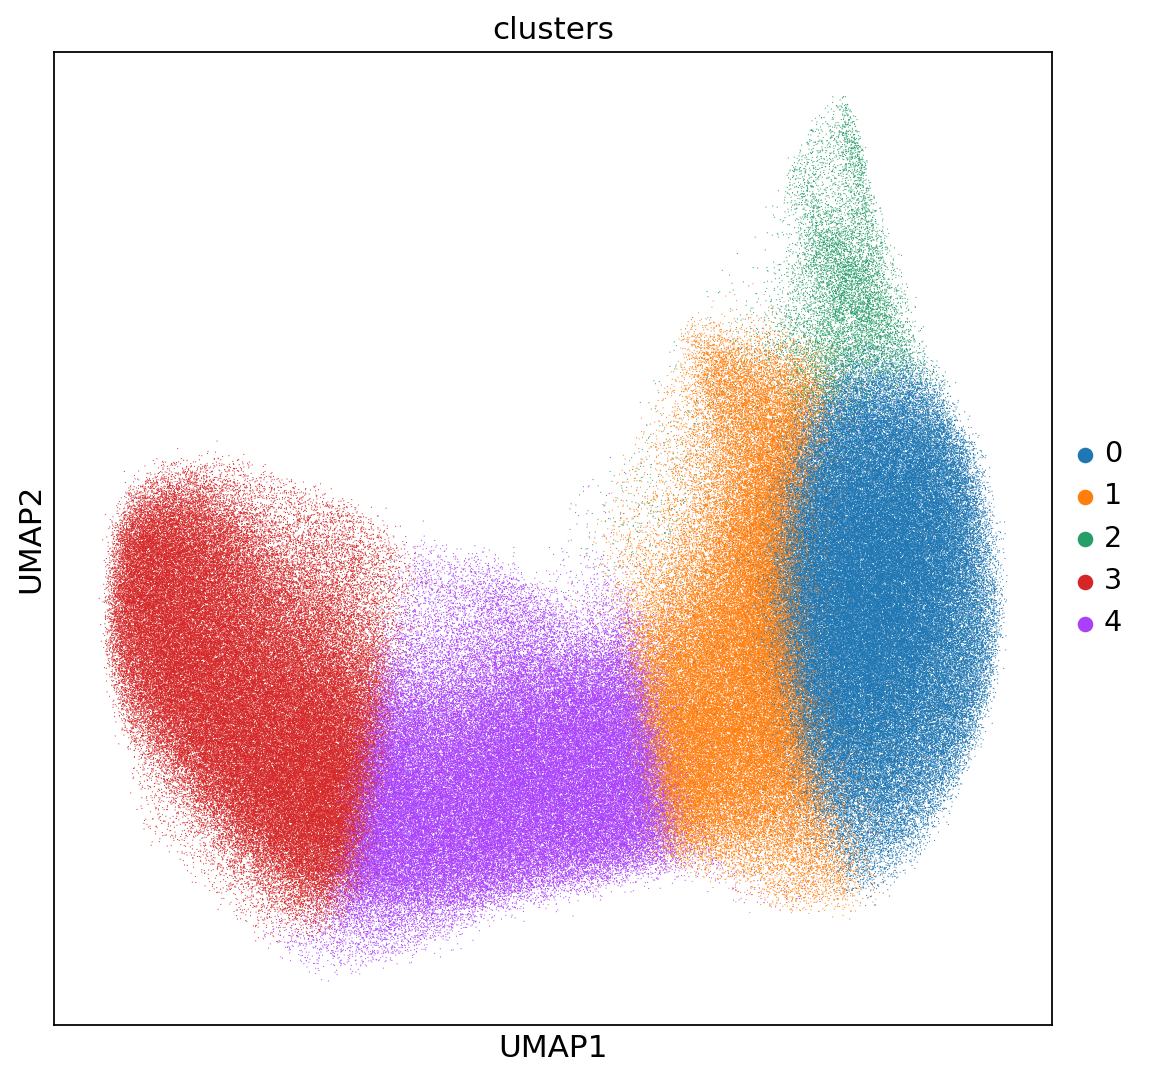

In [16]:
sc.pl.umap(adata, color="clusters", s=1)